##1. Gerekli Kütüphanelerin İçe Aktarılması

Bu hücrede proje boyunca kullanılacak temel kütüphaneler içe aktarılmaktadır. NumPy ve pandas veri işleme için, matplotlib ve seaborn görselleştirme için kullanılmaktadır. TensorFlow ve Keras ise Variational Autoencoder modelinin kurulması ve eğitilmesi için gereklidir.

Ayrıca veri hazırlama sürecinde kullanılacak `MinMaxScaler`, `train_test_split`, `OneHotEncoder` ve `ColumnTransformer` gibi araçlar da burada tanımlanmaktadır. Bu yapı sayesinde hem veri ön işleme hem model eğitimi hem de performans değerlendirme adımları tek bir akış içinde yürütülebilmektedir.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from io import StringIO

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

## 2. Veri Dosyasını DataFrame Formatına Dönüştüren Yardımcı Fonksiyon

Bu hücrede veri dosyasını okuyup pandas DataFrame formatına dönüştüren bir yardımcı fonksiyon tanımlanmaktadır. Fonksiyon, dosya içinde `@data` satırını bulduktan sonra gerçek veri kısmını ayırmakta ve bu kısmı tablo yapısına çevirmektedir.

Bu yaklaşım, veri dosyasının doğrudan standart bir CSV gibi okunamadığı durumlarda daha kontrollü bir yükleme sağlar. Ayrıca sütun sayısı kontrol edilerek veri setinin beklenen yapıda olup olmadığı da doğrulanmaktadır. Böylece sonraki adımlarda oluşabilecek biçim hatalarının önüne geçilmiş olur.

In [ ]:
def load_dataset_flexible(path, columns_42, columns_43=None):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    data_start = None
    for i, line in enumerate(lines):
        if line.strip().lower() == "@data":
            data_start = i + 1
            break

    if data_start is not None:
        data_lines = []
        for line in lines[data_start:]:
            line = line.strip()
            if not line or line.startswith("%"):
                continue
            data_lines.append(line)

        data_text = "\n".join(data_lines)
        df = pd.read_csv(StringIO(data_text), header=None)
    else:
        df = pd.read_csv(path, header=None)

    if df.shape[1] == len(columns_42):
        df.columns = columns_42
    elif columns_43 is not None and df.shape[1] == len(columns_43):
        df.columns = columns_43
    else:
        raise ValueError(
            f"Sütun sayısı uyuşmuyor. "
            f"Bulunan: {df.shape[1]}, "
            f"Beklenen: {len(columns_42)} veya {len(columns_43) if columns_43 is not None else 'yok'}"
        )

    return df

## 3. Veri Seti Sütun İsimlerinin Tanımlanması


Bu hücrede NSL-KDD veri setinde kullanılacak sütun isimleri tanımlanmaktadır. Veri setinin bazı sürümlerinde yalnızca temel öznitelikler ve etiket bulunurken, bazı sürümlerinde buna ek olarak `difficulty` sütunu da yer alabilmektedir. Bu nedenle iki farklı sütun listesi hazırlanmıştır.

Bu tanımlama sayesinde veri yükleme aşamasında sütunlar anlamlı isimlerle eşleştirilir ve verinin hangi değişkenlerden oluştuğu açık biçimde görülür. Böylece hem kodun okunabilirliği artar hem de sonraki ön işleme adımları daha düzenli ilerler.

In [ ]:
col_names_42 = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label"
]

col_names_43 = col_names_42 + ["difficulty"]

## 4. Eğitim ve Test Veri Setlerinin Yüklenmesi


Bu hücrede eğitim ve test veri setleri daha önce tanımlanan yardımcı fonksiyon kullanılarak yüklenmektedir. Dosyalar tablo formatına çevrildikten sonra veri boyutları ve ilk birkaç satır ekrana yazdırılmaktadır.

Bu ilk kontrol adımı oldukça önemlidir. Çünkü verinin doğru okunup okunmadığı, satır ve sütun sayılarının beklenen yapıda olup olmadığı ve sütun isimlerinin doğru eşleşip eşleşmediği bu aşamada kolayca görülebilir. Böylece model kurulumuna geçmeden önce veri yapısı doğrulanmış olur.

In [ ]:
train_df = load_dataset_flexible(
    "/content/sample_data/KDDTrain+.txt",
    columns_42=col_names_42,
    columns_43=col_names_43
)

test_df = load_dataset_flexible(
    "/content/sample_data/KDDTest+.txt",
    columns_42=col_names_42,
    columns_43=col_names_43
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())

Train shape: (125973, 43)
Test shape: (22544, 42)
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0

## 5. Etiketlerin İkili Sınıfa Dönüştürülmesi


Bu hücrede veri setindeki özgün saldırı türleri, anomali tespiti problemine uygun olacak şekilde ikili sınıf yapısına dönüştürülmektedir. Normal trafik örnekleri `0`, saldırı içeren tüm örnekler ise `1` olarak etiketlenmektedir.

Bu dönüşümün amacı, çok sayıda farklı saldırı tipini tek tek sınıflandırmak yerine problemi “normal” ve “anormal” ayrımı üzerinden kurmaktır. Bu yaklaşım, VAE tabanlı anomali tespiti için daha uygundur. Ayrıca sınıf dağılımının yazdırılması, veride normal ve saldırı örneklerinin oranını görmek açısından faydalıdır.

In [ ]:
train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

print(train_df["binary_label"].value_counts())
print(test_df["binary_label"].value_counts())

binary_label
0    67343
1    58630
Name: count, dtype: int64
binary_label
1    12833
0     9711
Name: count, dtype: int64


## 6. Kategorik Özelliklerin One-Hot Encoding ile Sayısallaştırılması


Bu hücrede veri setindeki kategorik ve sayısal değişkenler ayrılmaktadır. `protocol_type`, `service` ve `flag` sütunları kategorik özellik olarak ele alınırken, diğer değişkenler sayısal özellikler olarak bırakılmaktadır. Daha sonra `ColumnTransformer` yardımıyla bu iki özellik grubu için ortak bir ön işleme yapısı kurulmaktadır.

Kategorik sütunlarda `OneHotEncoder` kullanılması, bu değişkenlerin modele daha uygun biçimde aktarılmasını sağlar. Sayısal sütunlar ise doğrudan korunur. Böylece veri setindeki farklı tipteki özellikler aynı anda ve düzenli bir şekilde dönüştürülebilir.

In [ ]:
categorical_cols = ["protocol_type", "service", "flag"]
numeric_cols = [col for col in X_train_raw.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

## 7. Model Girdileri ve Hedef Etiketlerinin Ayrıştırılması


Bu hücrede veri seti modelin kullanacağı giriş değişkenleri ve değerlendirme için kullanılacak hedef etiketler olarak ayrılmaktadır. `label` ve `binary_label` sütunları hedef bilgisi taşıdığı için giriş değişkenlerinden çıkarılmaktadır. Eğer veri setinde `difficulty` sütunu varsa, bu sütun da model girdisine dahil edilmemektedir.

Bu adım sonunda `X_train_raw` ve `X_test_raw` yalnızca öznitelikleri içeren ham giriş matrislerini temsil ederken, `y_train_all` ve `y_test` hedef etiketleri temsil etmektedir. Böylece veri, modelleme sürecine uygun biçimde iki parçaya ayrılmış olur.

In [ ]:
drop_cols_train = ["label", "binary_label"]
if "difficulty" in train_df.columns:
    drop_cols_train.append("difficulty")

drop_cols_test = ["label", "binary_label"]
if "difficulty" in test_df.columns:
    drop_cols_test.append("difficulty")

X_train_raw = train_df.drop(columns=drop_cols_train)
y_train_all = train_df["binary_label"]

X_test_raw = test_df.drop(columns=drop_cols_test)
y_test = test_df["binary_label"]

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw:", X_test_raw.shape)

X_train_raw: (125973, 41)
X_test_raw: (22544, 41)


## 8. Sadece Normal Verilerin Eğitim İçin Seçilmesi

Bu hücrede modelin öğrenmesi için yalnızca normal trafik örnekleri seçilmektedir. Çünkü anomali tespitinde amaç, modele saldırıları öğretmek değil, normal davranışın yapısını öğretmektir. Bu nedenle `binary_label = 0` olan örnekler alınarak eğitim verisi oluşturulmaktadır.

Bu yaklaşımın temel mantığı şudur: model normal örnekleri iyi öğrenirse, normal olmayan örnekleri yeniden oluştururken daha fazla hata yapar. Böylece saldırılar doğrudan sınıf bilgisiyle değil, reconstruction error üzerinden ayırt edilebilir hale gelir.

In [ ]:
X_train_normal_raw = X_train_raw[y_train_all == 0]

print("Normal eğitim verisi boyutu:", X_train_normal_raw.shape)

Normal eğitim verisi boyutu: (67343, 41)


## 9. Normal Eğitim Verisinin Eğitim ve Doğrulama Kümelerine Ayrılması


Bu hücrede yalnızca normal örneklerden oluşan veri kümesi iki parçaya ayrılmaktadır: eğitim kümesi ve doğrulama kümesi. Eğitim kümesi modelin öğrenmesi için kullanılırken, doğrulama kümesi eğitim sürecinin takibi ve eşik değeri belirleme aşaması için kullanılmaktadır.

Bu ayrım, modelin yalnızca eğitim verisini ezberleyip ezberlemediğini kontrol etmek açısından önemlidir. Aynı zamanda doğrulama kümesi üzerinde elde edilen reconstruction error değerleri, daha sonra anomali eşiğinin daha sağlıklı biçimde seçilmesine yardımcı olur.

In [ ]:
X_train_normal_raw, X_val_normal_raw = train_test_split(
    X_train_normal_raw,
    test_size=0.2,
    random_state=42
)

print("Train normal:", X_train_normal_raw.shape)
print("Val normal:", X_val_normal_raw.shape)

Train normal: (53874, 41)
Val normal: (13469, 41)


## 10. Verinin Encode Edilmesi ve Ölçeklendirilmesi

Bu hücrede veri, model eğitimi için uygun hale getirilmektedir. İlk olarak kategorik değişkenler ön işleme yapısı kullanılarak sayısal forma dönüştürülmektedir. Daha sonra tüm özellikler `MinMaxScaler` ile 0 ile 1 aralığına taşınmaktadır.

Bu işlem özellikle VAE modeli için faydalıdır. Çünkü giriş verisinin belirli bir aralıkta olması, modelin daha dengeli öğrenmesine yardımcı olur. Ayrıca decoder çıkışında sigmoid aktivasyonu kullanıldığı için giriş değerlerinin benzer ölçekte olması yeniden oluşturma sürecini daha tutarlı hale getirir.

In [ ]:
X_train_normal_encoded = preprocessor.fit_transform(X_train_normal_raw)
X_val_normal_encoded = preprocessor.transform(X_val_normal_raw)
X_test_encoded = preprocessor.transform(X_test_raw)

scaler = MinMaxScaler()

X_train_normal = scaler.fit_transform(X_train_normal_encoded)
X_val_normal = scaler.transform(X_val_normal_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("X_train_normal:", X_train_normal.shape)
print("X_val_normal:", X_val_normal.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_normal: (53874, 77)
X_val_normal: (13469, 77)
X_test_scaled: (22544, 77)


## 11. Tekrarlanabilirlik İçin Rastgelelik Ayarlarının Sabitlenmesi

Bu hücrede deneyin daha tutarlı sonuçlar vermesi için rastgelelik kaynakları sabitlenmektedir. Python, NumPy ve TensorFlow tarafında aynı seed değeri kullanılarak modelin her çalıştırmada benzer davranış göstermesi amaçlanmaktadır.

Bu adım özellikle derin öğrenme çalışmalarında önemlidir. Çünkü ağırlık başlangıçları, veri bölmeleri ve örnekleme süreçleri rastgeleliğe bağlı olabilir. Seed sabitlemek, sonuçların daha kararlı yorumlanmasına yardımcı olur.

In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

## 12. Latent Uzay Boyutunun ve Sampling Katmanının Tanımlanması

Bu hücrede VAE modelinin gizli uzay boyutu belirlenmekte ve örnekleme işlemini yapan özel katman tanımlanmaktadır. `latent_dim = 8` ifadesi, verinin daha düşük boyutlu bir temsile dönüştürüleceğini göstermektedir.

Sampling katmanı ise VAE’nin en ayırt edici parçalarından biridir. Encoder doğrudan tek bir latent vektör üretmek yerine ortalama ve varyans bilgisi üretir. Daha sonra bu bilgiler kullanılarak latent uzaydan örnekleme yapılır. Bu yapı, VAE’yi klasik autoencoder’dan ayıran temel özelliklerden biridir.

In [ ]:
latent_dim = 8
input_dim = X_train_normal.shape[1]

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

## 13. VAE Encoder Mimarisinin Oluşturulması

Bu hücrede VAE modelinin encoder bölümü tanımlanmaktadır. Encoder, giriş verisini alır ve onu daha düşük boyutlu latent uzayda temsil edecek istatistiksel parametrelere dönüştürür. Burada iki yoğun katmandan sonra `z_mean` ve `z_log_var` değerleri üretilmektedir.

Bu yapı sayesinde model, her örnek için yalnızca tek bir sıkıştırılmış vektör değil, o vektörün dağılım bilgilerini de öğrenir. Daha sonra sampling katmanı ile bu dağılımdan bir latent temsil elde edilir. Böylece model, veriyi daha esnek ve olasılıksal bir biçimde temsil edebilir.

In [ ]:
encoder_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(encoder_inputs)
x = layers.Dense(32, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 77)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,992 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 8)         │        264 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 8)         │        264 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 8)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,600 (29.69 KB)

 Trainable params: 7,600 (29.69 KB)

 Non-trainable params: 0 (0.00 B)

## 14. VAE Decoder Mimarisinin Oluşturulması

Bu hücrede VAE modelinin decoder bölümü tanımlanmaktadır. Decoder’ın görevi, latent uzaydan gelen sıkıştırılmış temsili tekrar giriş uzayına dönüştürmektir. Yani model burada öğrendiği gizli temsilden orijinal veriyi yeniden oluşturmaya çalışmaktadır.

Son katmanda sigmoid aktivasyonu kullanılması, çıktı değerlerinin 0 ile 1 aralığında kalmasını sağlar. Bu da daha önce uygulanan min-max ölçeklendirme ile uyumlu bir yapı oluşturur. Sonuç olarak decoder, normal veriyi mümkün olduğunca doğru biçimde yeniden üretmeye çalışır.

In [ ]:
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(32, activation="relu")(latent_inputs)
x = layers.Dense(64, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="sigmoid")(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 77)             │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,405 (28.93 KB)

 Trainable params: 7,405 (28.93 KB)

 Non-trainable params: 0 (0.00 B)

## 15. VAE Sınıfının ve Kayıp Fonksiyonunun Tanımlanması

Bu hücrede encoder ve decoder bir araya getirilerek tam Variational Autoencoder yapısı oluşturulmaktadır. Modelin `call` fonksiyonu içinde önce encoder çalıştırılmakta, ardından elde edilen latent temsil decoder’a verilerek yeniden oluşturulmuş çıktı elde edilmektedir.

Ayrıca bu hücrede VAE’nin kayıp yapısı da tanımlanmaktadır. Toplam kayıp iki parçadan oluşur: reconstruction loss ve KL loss. Reconstruction loss, giriş ile yeniden oluşturulan çıktı arasındaki farkı ölçer. KL loss ise latent uzayın daha düzenli ve anlamlı bir dağılım izlemesini sağlar. Bu iki terim birlikte, modelin hem veriyi iyi öğrenmesini hem de latent uzayda daha kontrollü bir temsil üretmesini sağlar.

In [ ]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(inputs - reconstructed), axis=1)
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        self.add_loss(reconstruction_loss + kl_loss)
        return reconstructed

## 16. VAE Modelinin Oluşturulması ve Derlenmesi

Bu hücrede tanımlanan encoder ve decoder yapıları kullanılarak tam VAE modeli oluşturulmaktadır. Daha sonra model `adam` optimizasyon yöntemi ile derlenmektedir.

Bu aşama, modelin artık eğitime hazır hale geldiğini gösterir. Kayıp fonksiyonu model sınıfı içinde tanımlandığı için burada ayrıca bir loss belirtmeye gerek kalmadan derleme işlemi tamamlanmaktadır.

In [ ]:
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

## 17. VAE Modelinin Eğitilmesi

Bu hücrede VAE modeli yalnızca normal trafik verileri üzerinde eğitilmektedir. Giriş verisi aynı zamanda hedef olarak verilmektedir; çünkü modelin amacı sınıf tahmini yapmak değil, normal veriyi mümkün olduğunca doğru şekilde yeniden oluşturmaktır.

Eğitim sırasında `EarlyStopping` kullanılması, doğrulama kaybı iyileşmeyi bıraktığında eğitimin durmasını sağlar. Böylece modelin gereksiz yere uzun süre eğitilmesi engellenir ve en iyi doğrulama sonucunu veren ağırlıklar korunur. Bu da daha dengeli bir eğitim süreci sağlar.

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = vae.fit(
    X_train_normal,
    X_train_normal,
    epochs=50,
    batch_size=256,
    validation_data=(X_val_normal, X_val_normal),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 8.9101 - val_loss: 2.1903
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1562 - val_loss: 2.1663
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1363 - val_loss: 2.1532
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1307 - val_loss: 2.1488
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1256 - val_loss: 2.1270
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0964 - val_loss: 2.1046
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.0875 - val_loss: 2.0912
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0627 - val_loss: 2.0738
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0465 - val_loss: 2.0642
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0384 - val_loss: 2.0582
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.0357 - val_loss: 2.0665
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

## 18. Eğitim ve Doğrulama Kayıplarının Görselleştirilmesi

Bu hücrede model eğitimi sırasında elde edilen eğitim ve doğrulama kayıpları grafik üzerinde gösterilmektedir. Böylece modelin epoch ilerledikçe nasıl öğrendiği ve doğrulama verisi üzerinde nasıl davrandığı görsel olarak incelenebilmektedir.

Bu grafik, modelin kararlı şekilde öğrenip öğrenmediğini anlamak açısından önemlidir. Eğitim ve doğrulama kayıplarının birlikte değerlendirilmesi, aşırı öğrenme veya yetersiz öğrenme gibi durumların fark edilmesine yardımcı olur.

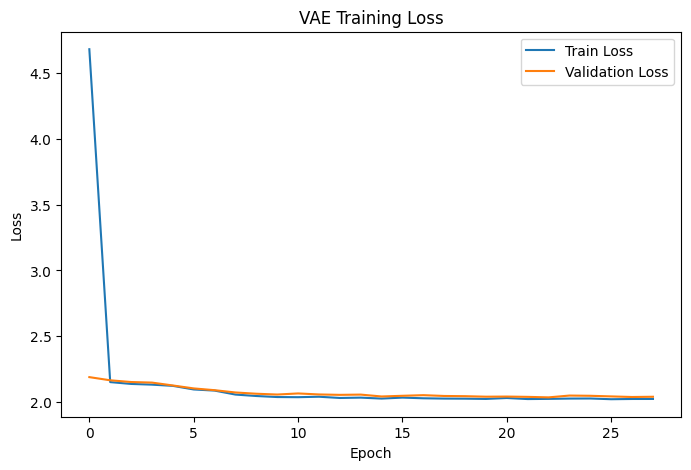

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.show()

## 19. Rekonstrüksiyon Hatasının Hesaplanması

Bu hücrede modelin anomali tespitinde kullanacağı temel skor hesaplanmaktadır. Her örnek için giriş verisi ile modelin yeniden oluşturduğu çıktı arasındaki fark alınmakta ve kare hata toplamı üzerinden reconstruction error değeri elde edilmektedir.

Bu değer anomali tespitinin merkezindedir. Normal örnekler model tarafından daha iyi yeniden oluşturulduğu için hata genellikle daha düşük olur. Saldırı veya anormal örneklerde ise model daha fazla hata yapar. Bu nedenle reconstruction error yükseldikçe örneğin anormal olma ihtimali de artar.

In [ ]:
def get_reconstruction_error(model, data):
    reconstructed = model.predict(data, verbose=0)
    error = np.sum(np.square(data - reconstructed), axis=1)
    return error

val_errors = get_reconstruction_error(vae, X_val_normal)
test_errors = get_reconstruction_error(vae, X_test_scaled)

## 20. Anomali Eşiğinin Belirlenmesi ve Tahminlerin Üretilmesi

Bu hücrede reconstruction error değerleri ikili karara dönüştürülmektedir. Bunun için doğrulama kümesindeki hata dağılımı üzerinden farklı eşik değerleri denenmekte ve her biri için precision, recall, F1-score ve false positive rate hesaplanmaktadır.

Daha sonra bu adaylar arasından en iyi F1-score değerini veren eşik seçilmekte ve test verisi üzerinde son tahminler üretilmektedir. Bu yaklaşım, eşik değerinin rastgele seçilmesi yerine daha kontrollü ve karşılaştırmalı biçimde belirlenmesini sağlar.

In [ ]:
candidate_percentiles = [90, 92.5, 95, 97.5, 99]

threshold_results = []

for p in candidate_percentiles:
    th = np.percentile(val_errors, p)
    y_pred_temp = (test_errors > th).astype(int)

    precision_temp = precision_score(y_test, y_pred_temp)
    recall_temp = recall_score(y_test, y_pred_temp)
    f1_temp = f1_score(y_test, y_pred_temp)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
    fpr_temp = fp / (fp + tn)

    threshold_results.append([p, th, precision_temp, recall_temp, f1_temp, fpr_temp])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=["Percentile", "Threshold", "Precision", "Recall", "F1-score", "FPR"]
)

best_row = threshold_df.loc[threshold_df["F1-score"].idxmax()]
best_percentile = best_row["Percentile"]
threshold = best_row["Threshold"]
best_f1 = best_row["F1-score"]

print("Seçilen percentile:", best_percentile)
print("Seçilen threshold:", threshold)
print("Bu threshold için F1-score:", best_f1)

y_pred = (test_errors > threshold).astype(int)

Seçilen percentile: 90.0
Seçilen threshold: 4.11451596195659
Bu threshold için F1-score: 0.801109917651271


## 21. Model Performansının Metriklerle Değerlendirilmesi

Bu hücrede modelin test verisi üzerindeki başarımı farklı metriklerle ölçülmektedir. `ROC-AUC`, modelin skor düzeyinde normal ve saldırı örneklerini ne kadar iyi ayırabildiğini gösterir. `Precision`, `Recall` ve `F1-score` ise seçilen eşik altında elde edilen sınıflandırma performansını özetler.

Ayrıca karmaşıklık matrisi yardımıyla `False Positive Rate` hesaplanmaktadır. Bu metrik, normal örneklerin ne kadarının yanlış biçimde saldırı olarak işaretlendiğini gösterir. Böylece modelin hem saldırı yakalama gücü hem de yanlış alarm üretme eğilimi birlikte değerlendirilebilir.

In [ ]:
roc_auc = roc_auc_score(y_test, test_errors)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)

print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"FPR       : {fpr:.4f}")

ROC-AUC   : 0.9343
Precision : 0.9410
Recall    : 0.6974
F1-score  : 0.8011
FPR       : 0.0578


## 22. Karmaşıklık Matrisinin Görselleştirilmesi

Bu hücrede modelin sınıflandırma sonuçları karmaşıklık matrisi ile görselleştirilmektedir. Bu matris, doğru negatif, yanlış pozitif, yanlış negatif ve doğru pozitif sayılarını açık biçimde göstermektedir.

Bu görsel, modelin ne tür hatalar yaptığını daha net anlamayı sağlar. Özellikle saldırıların ne kadarının yakalandığı ve normal trafiğin ne kadarında yanlış alarm oluştuğu bu tablo üzerinden kolayca yorumlanabilir.

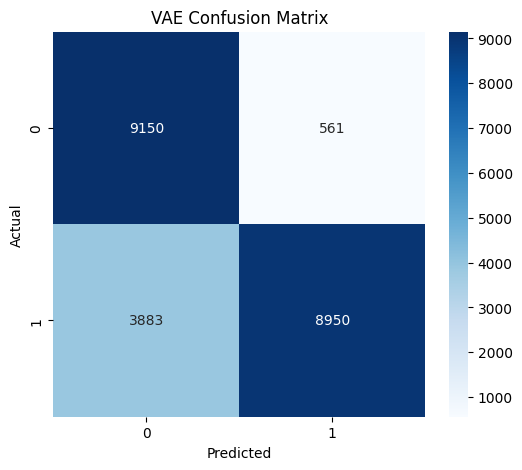

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("VAE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 23. ROC Eğrisinin Çizdirilmesi

Bu hücrede modelin farklı eşik değerleri altında nasıl davrandığını gösteren ROC eğrisi çizdirilmektedir. Eğri üzerindeki her nokta, başka bir threshold seçimine karşılık gelir ve true positive rate ile false positive rate arasındaki ilişkiyi gösterir.

ROC eğrisi, modelin yalnızca tek bir eşik değeri altında değil, genel ayırt etme gücü açısından değerlendirilmesine yardımcı olur. Eğri altında kalan alanın büyük olması, modelin normal ve saldırı örneklerini genel olarak iyi ayırt ettiğini gösterir.

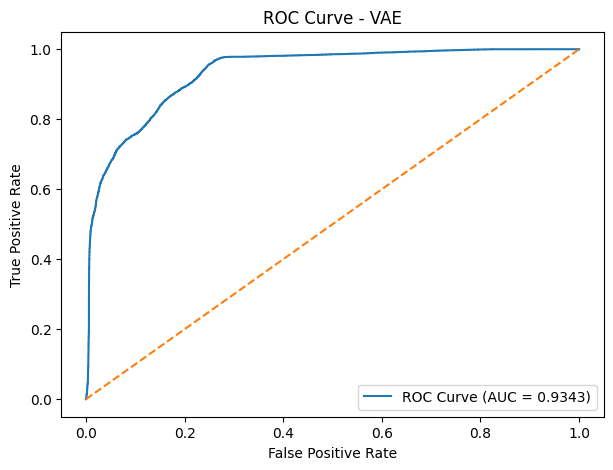

In [ ]:
fpr_curve, tpr_curve, _ = roc_curve(y_test, test_errors)

plt.figure(figsize=(7, 5))
plt.plot(fpr_curve, tpr_curve, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VAE")
plt.legend()
plt.show()

## 24. Rekonstrüksiyon Hatası Dağılımının Görselleştirilmesi

Bu hücrede test verisindeki reconstruction error değerleri normal ve saldırı örnekleri için ayrı ayrı görselleştirilmektedir. Ayrıca seçilen anomali eşiği dikey bir çizgi ile gösterilmektedir.

Bu grafik, modelin anomali tespiti mantığını anlamak açısından oldukça faydalıdır. Normal örneklerin hata dağılımı genellikle daha düşük bölgede toplanırken, saldırı örneklerinin daha yüksek hata üretmesi beklenir. Eşik çizgisi ise bu iki bölge arasında karar sınırını temsil eder.

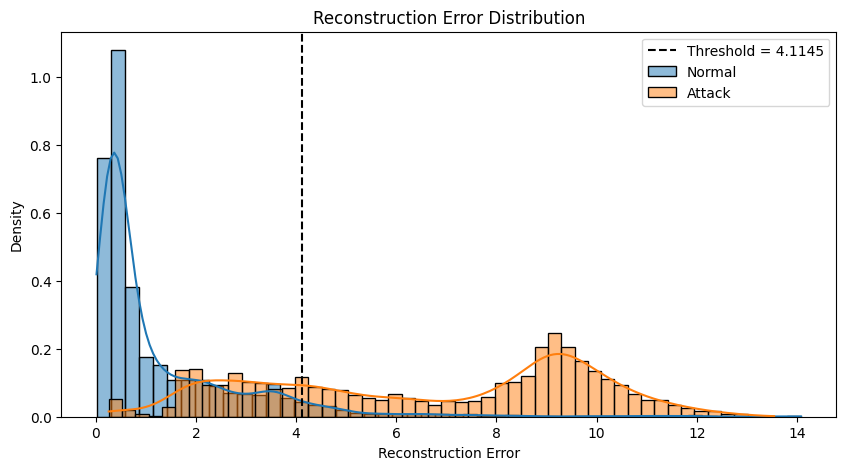

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(test_errors[y_test == 0], label="Normal", kde=True, stat="density", bins=50)
sns.histplot(test_errors[y_test == 1], label="Attack", kde=True, stat="density", bins=50)
plt.axvline(threshold, color="black", linestyle="--", label=f"Threshold = {threshold:.4f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()

## 25. Sonuçların Tablo Halinde Özetlenmesi

Bu hücrede modelden elde edilen temel performans metrikleri tek satırlık bir tablo halinde özetlenmektedir. Tablo içinde model adı, seçilen threshold değeri ve değerlendirme metrikleri birlikte gösterilmektedir.

Bu özet tablo, sonuçların raporlanmasını kolaylaştırır. Aynı zamanda ileride farklı model ya da farklı parametrelerle yapılan denemelerle yan yana karşılaştırma yapılmasına da uygun bir yapı sunar.

In [ ]:
results = pd.DataFrame({
    "Model": ["VAE"],
    "Selected Threshold": [threshold],
    "ROC-AUC": [roc_auc],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "FPR": [fpr]
})

results

,Model,Selected Threshold,ROC-AUC,Precision,Recall,F1-score,FPR
0,VAE,4.114516,0.934257,0.941016,0.697421,0.80111,0.05777


## 26. Threshold Analiz Sonuçlarının Görselleştirilmesi

Bu hücrede farklı eşik değerleri için elde edilen performans sonuçları grafik üzerinde karşılaştırılmaktadır. Precision, recall, F1-score ve FPR değerlerinin threshold değiştikçe nasıl davrandığı aynı anda görülebilmektedir.

Bu grafik, eşik seçiminin model davranışını ne kadar etkilediğini açık biçimde gösterir. Daha düşük eşikler genellikle daha fazla saldırı yakalamayı sağlarken yanlış alarmı artırabilir; daha yüksek eşikler ise yanlış alarmı azaltırken bazı saldırıların kaçmasına neden olabilir. Bu nedenle threshold analizi, anomali tespiti çalışmalarında önemli bir adımdır.

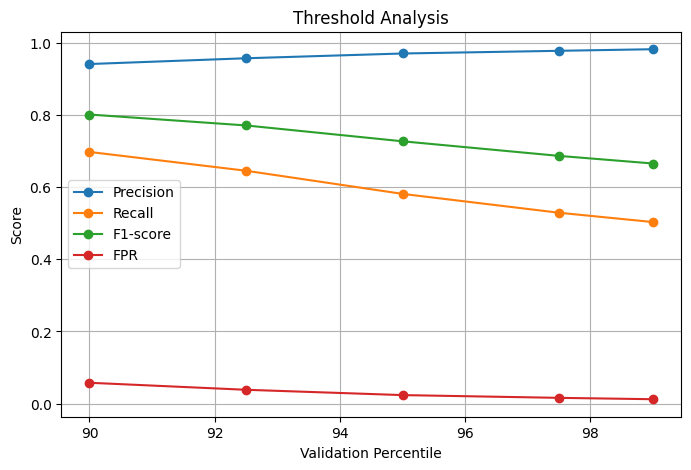

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Percentile"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Percentile"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Percentile"], threshold_df["F1-score"], marker="o", label="F1-score")
plt.plot(threshold_df["Percentile"], threshold_df["FPR"], marker="o", label="FPR")

plt.xlabel("Validation Percentile")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.grid(True)
plt.show()